# Vectorcalculus

In dit werkblad zullen we Sympy gebruiken om berekeningen te automatiseren in verband met functies van meerdere variabelen, vectorvelden en oppervlakken.

De functionaliteit voor vectorcalculus binnen Sympy is enorm verbeterd vanaf versie 1.7. Het is nu mogelijk om parametrische regios te definiëren en deze vervolgens te gebruiken om lijn- en oppervlakteintegralen uit te rekenen. Je kan ook vectoren en vectorvelden vrij intuitief definiëren en bijvoorbeeld de gradient, curl of divergentie ervan bepalen.

In [1]:
import numpy as np
import sympy as sp
import sympy.vector as sv
import matplotlib.pyplot as plt

We hebben de Sympy, Numpy en Matplotlib packages ingeladen, en hebben ook de vector module uit sympy geimporteerd als `sv`. Als we functionaliteit uit dit pakket nodig hebben, zullen we moeten prefixen met `sv.`.

In [2]:
t, u, v, x, y = sp.symbols("t, u, v, x, y")

# 2D parameterkrommen

Via sympy kunnen we parameterkrommen in 2D definiëren. Hiervoor geef je een parametervergelijking in van de kromme, gevolgd door de grenzen van de parameter. Het volgende stukje code definieert een cirkel in het vlak met straal 2, eenmaal doorlopen in tegenwijzerszin.

In [3]:
circle = sp.Curve((2 * sp.cos(t), 2 * sp.sin(t)), (t, 0, 2*sp.pi))

Bij een 2D kromme heb je rechtstreeks toegang tot de componentsfuncties en het parameterinterval via de attributen `limits` en `functions`:

In [4]:
interval = circle.limits
display(interval)

(t, 0, 2*pi)

In [5]:
c1 = circle.functions[0]
c2 = circle.functions[1]
display(c1, c2)

2*cos(t)

2*sin(t)

Je kan ook een waarde voor `t` substitueren om een punt op de kromme te vinden:

In [6]:
punt = circle.subs(t, sp.pi)
display(punt)

Point2D(-2, 0)

In [7]:
display(punt.x)
display(punt.y)

-2

0

We kunnen deze kromme laten plotten met Sympy, hiervoor zullen we functie `plot_parametric` gebruiken uit de plotting module. Deze functie zijn we al eerder tegengekomen in het werkblad **02_functies**. Je kan documentatie over deze methode vinden op https://docs.sympy.org/latest/modules/plotting.html. Omdat deze zich in een aparte module bevindt binnen sympy, zullen we deze nog expliciet moeten aanroepen door middel van `sp.plotting`. Voor de rest is de code vrij eenvoudig: je geeft de componentsfuncties mee en het interval voor de bijhorende parameter.

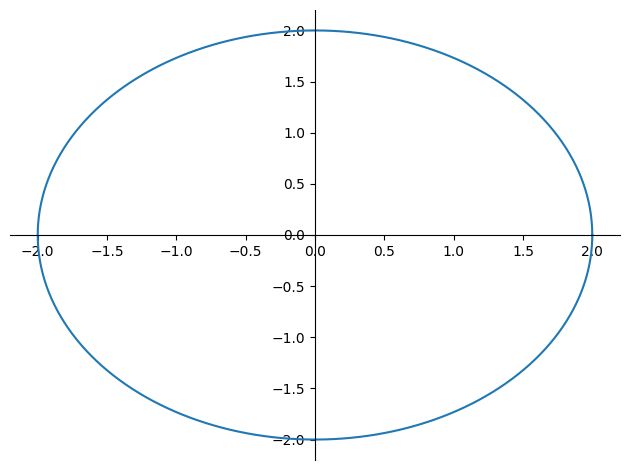

In [8]:
sp.plotting.plot_parametric(c1, c2, interval)

Merk op dat dit op het eerste zicht geen cirkel is. Dit is geen fout in onze vergelijkingen maar is te wijten aan het feit dat het plotvenster rechthoekig is. Je kan dit vermijden door het extra argument `aspect_ratio` mee te geven (dit werkt ook voor Matplotlib). Standaard staat dit op `"auto"`, hier geven we echter het tuple `(1, 1)` mee. Dit tuple definieert de aspect ratio van de x en y assen: indien je dit zet op `(2, 1)` zal de ratio van de x-as ten opzichte van de y-as `2:1` zijn (probeer dit maar).

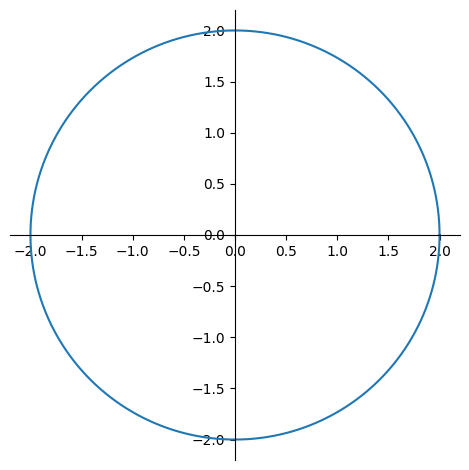

In [9]:
sp.plotting.plot_parametric(c1, c2, interval, aspect_ratio=(1, 1))

**Opmerking** In Calculus I hebben we Numpy/Matplotlib gebruikt (soms door functies om te zetten via `lambdify`) om een parameterkromme te plotten. Je kan een kijkje nemen in het werkblad over gevorderde grafieken `06_gevorderdegrafieken` hoe dit net in zijn werk ging. De combinatie van Numpy en Matplotlib is dé tool bij uitstek als je plots wil maken met volledige controle over de assen, labels etc. om te publiceren in papers.

De `plot_parametric` methode volstaat echter om snel een eenvoudige plot te maken van een parameterkromme.

# 3D parameterkrommen en oppervlakken

We kunnen met behulp van Sympy ook een kromme definiëren in $\mathbb{R}^3$ met behulp van een [`ParametricRegion`](https://docs.sympy.org/latest/modules/vector/api/classes.html#parametricregion). Deze klasse kan je gebruiken om een parametervoorstelling van een 3D kromme te definiëren, analoog aan de `sp.Curve` methode hierboven die gebruikt wordt in 2 dimensies.

**Opdracht 1**: Definieer de volgende parameterkromme met behulp van een `ParametricRegion`

$$ \mathbf{r}(t) = t~\mathbf{i} + t^2~\mathbf{j} + t^3~\mathbf{k}, \qquad 0 \leq t \leq 1. $$

Dit kan je op dezelfde manier doen als voor de 2D kromme, je hebt twee argumenten nodig: eentje voor de componentsfuncties, en eentje voor de grenzen van de parameter. Denk eraan dat `ParametricRegion` uit de `sympy.vector` module komt, dus je zal moeten prefixen met `sv.`.

In [10]:
parameter = sv.ParametricRegion((t, t**2, t**3), (t, 0, 1))
parameter

ParametricRegion((t, t**2, t**3), (t, 0, 1))

Analoog aan de 2D case heb je hier ook toegang tot de componentsfuncties en het parameterinterval via de attributen `definition` en `limits`. Toon deze hieronder. Merk op dat de uitvoer van `limits` in het 2D geval een tuple is, maar hier een dictionary (je kan bijvoorbeeld een parametrisatie in $u$ en $v$ hebben, zie verder in de worksheet). Om het interval van bijvoorbeeld $t$ eruit te halen kan je `curve.limits[t]` doen (waarbij `curve` je parameterkromme is).

In [11]:
interval = parameter.limits
display(interval)

{t: (0, 1)}

In [12]:
parameter.limits[t]

(0, 1)

In [13]:
p1 = parameter.definition[0]
p2 = parameter.definition[1]
p3 = parameter.definition[2]
p3

t**3

**Opdracht 2**: Een 3D kromme kan je plotten met behulp van `plot3D_parametric_line`, je kan een kijkje nemen in de [documentatie van de plotting module](http://docs.sympy.org/latest/modules/plotting.html) hoe je deze methode aanroept. Plot vervolgens de kromme die je hierboven definieerde.

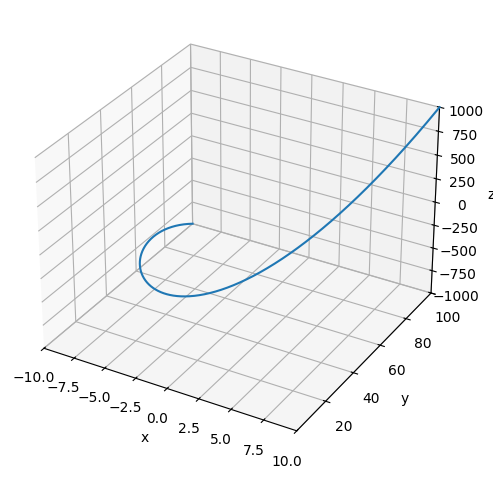

In [14]:
sp.plotting.plot3d_parametric_line(p1, p2, p3, interval)

**Opdracht 3**: Bestudeer de documentatie van de plotting module uit Sympy nog wat verder en laat de grafiek van de functie van twee variabelen

$$ f(x,y) = \sqrt{9-x^2-y^2} $$

tekenen met behulp van [`plot3d`](https://docs.sympy.org/latest/modules/plotting.html#sympy.plotting.plot.plot3d).

In [15]:
f = sp.Function('F')
x, y = sp.symbols('x, y')
f = sp.sqrt(9-x**2-y**2)

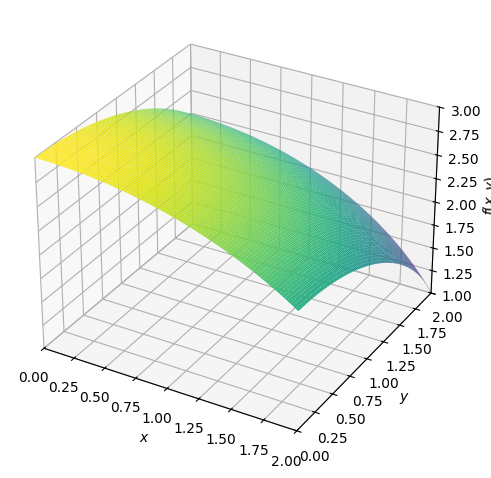

In [16]:
sp.plotting.plot3d(f, (x, 0, 2), (y, 0, 2))

Je zal opmerken dat het boloppervlak naar onder toe slordig is afgewerkt. We hebben eerder in het werkblad over gevorderde grafieken oppervlakken getekend via meshgrids, waarbij we zelf meer controle hebben over de kwaliteit van de plot.

**Opdracht 4.1**: Bij de vorige opdracht hebben we een boloppervlak getekend waarbij het functievoorschrift expliciet gegeven werd in functie van $x$ en $y$. We kunnen echter ook oppervlakken definieren met behulp van een parametrisatie. Ook hier kan je gebruik maken van `ParametricRegion`.

Definieer een parametrisatie in termen van $(u, v)$ dat overeenkomt met het deel van het boloppervlak dat in het eerste octant ligt. Dit kan je doen met behulp van sferische coordinaten als parametervoorstelling, in termen van $u$ en $v$. In dit geval zal `ParametricRegion` 3 argumenten nodig hebben: een tuple met de componentsfuncties, grenzen voor $u$, en grenzen voor $v$.

In [17]:
bol = sv.ParametricRegion((u**2+v**2), (u, 0, 10), (v, 0, 10))
bol

ParametricRegion((u**2 + v**2,), (u, 0, 10), (v, 0, 10))

In [18]:
x = sp.cos(u) * sp.sin(v)
y = sp.sin(u) * sp.sin(v)
z = sp.cos(v)

# Maak de ParametricRegion aan
# Grenzen voor het eerste octant: u van 0 tot pi/2, v van 0 tot pi/2
bol_regio = sv.ParametricRegion((x, y, z), (u, 0, sp.pi/2), (v, 0, sp.pi/2))
bol_regio

ParametricRegion((sin(v)*cos(u), sin(u)*sin(v), cos(v)), (u, 0, pi/2), (v, 0, pi/2))

In [26]:
functie = bol_regio.definition
limitu = (u, bol_regio.limits[u][0], bol_regio.limits[u][1])
limitv = (v, bol_regio.limits[v][0], bol_regio.limits[v][1])

**Opdracht 4.2**: Maak vervolgens een plot van dit oppervlak door gebruik te maken van de methode [`plot3d_parametric_surface`](https://docs.sympy.org/latest/modules/plotting.html#sympy.plotting.plot.plot3d_parametric_surface).

Je kan de grenzen eenvoudig aanpassen om andere delen van het boloppervlak te tekenen. Maak een nieuwe plot waarbij je het boloppervlak plot dat overeenkomt met $z > 0$.

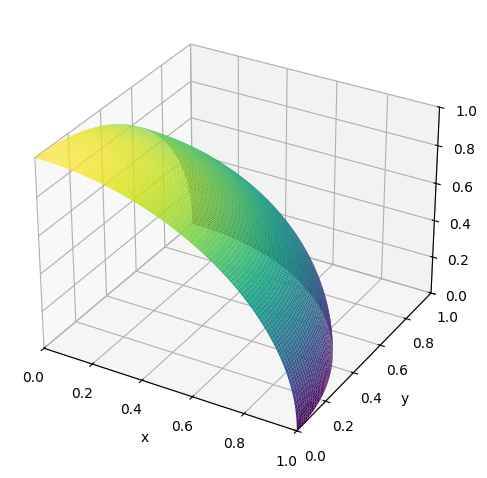

In [27]:
sp.plotting.plot3d_parametric_surface(functie, (u, 0, sp.pi/2), (v, 0, sp.pi/2))

Als je de plot van de halve bol vergelijkt met het resultaat van opdracht 3, wat valt je op?

Stel dat we een oppervlak willen definiëren waarbij de projectie op een van de coördinaatsvlakken geen rechthoek is maar een gebied waarbij de grenzen afhangen van de andere variabele. Dit vormt geen probleem voor sympy. Hieronder definiëren we het deel van het vlak $x + 2y + 3z = 6$ dat in het eerste octant ligt, dus boven de driehoek met hoekpunten $(0, 0)$, $(6, 0)$ en $(0, 3)$ in het $xy$-vlak.

In [28]:
surface = sv.ParametricRegion((u, v, 2 - 2*v/3 - u/3), (v, 0, 3-u/2), (u, 0, 6))
display(surface.definition)
display(surface.limits)

(u, v, -u/3 - 2*v/3 + 2)

{v: (0, 3 - u/2), u: (0, 6)}

Om een plot maken van dit oppervlak (met enkel het deel boven de driehoek) zul je wat creativiteit aan de dag moeten leggen. De methode `plot3d_parametric_surface` accepteert namelijk geen variabele integratiegrenzen. Het is echter mogelijk om via een coördinatentransformatie de driehoek in het $xy$-vlak om te vormen naar een rechthoek in het $(u, v)$-domein en zo de plot te tekenen. We laten het als doordenker voor de gemotiveerde student om uit te zoeken welke transformatie hiervoor nodig is en hoe dit te implementeren.

Oppervlakte-integralen uitrekenen over dit oppervlak zal lukken zonder gebruik te moeten maken van een coördinatentransformatie, zoals we later zullen zien.

# Studie van een harmonische functie

Nu komen we in het deel waarbij de `vector` module uit sympy echt tot zijn recht komt: vectorvelden en bijhorende operaties. Een belangrijk onderscheid dat we hier moeten maken is dat methodes uit deze module gebruik maken van een [coördinatenstelsel](https://docs.sympy.org/latest/modules/vector/basics.html#coordinate-systems-and-vectors) bestaande uit een gegeven set van basisvectoren. Dit laat gebruikers toe om bijvoorbeeld te wisselen tussen verschillende coördinatenstelsels of te werken met tensors. Dit zullen we niet behandelen in deze worksheet, geïnteresseerde studenten kunnen een kijkje nemen in de [documentatie](https://docs.sympy.org/latest/modules/vector/coordsys.html).

**opstellen van een coördinatenstelsel**

Zo'n coördinatenstelsel opstellen klinkt ingewikkeld, maar eigenlijk is dit zeer eenvoudig. Je kan gebruik maken van `CoordSys3D`, wat standaard een Cartesische geometrie heeft met de $x$, $y$ en $z$ assen als positievectoren. In het stukje code hieronder slaan we ons coordinatenstelsel op in `C` (van Cartesisch), en definiëren $x$, $y$ en $z$ als volgt.

In [30]:
C = sv.CoordSys3D("C")
x, y, z = C.x, C.y, C.z
display(x, y, z)

C.x

C.y

C.z

Merk op dat $x$, $y$ en $z$ vanaf nu in boldface geprint zullen worden om duidelijk te maken dat dit geen symbolen zijn, maar posities van ons coordinatenstelsel. De lege string `""` als argument betekent dat we geen expliciete naam geven aan ons stelsel, je kan dit eens veranderen naar `sv.CoordSys3D("C")` en kijken wat er gebeurt.

De posities **x**, **y** en **z** zijn in principe extensies van sympy-symbolen, wat betekent dat alle operaties die mogelijk zijn op een gewoon symbool ook hierop werken. Deze variabelen hebben echter meer functionaliteit dan symbolen alleen. Het is een goed idee om met dit type symbolen te werken zodra er vectoren of vectorvelden aan te pas komen, of wanneer je gradientoperaties op functies wil doen.

**Opdracht 5**: Definieer de functie $\phi(x, y, z)$ met voorschrift gegeven door

$$\phi(x,y,z) = \frac{\sin (\pi x) \sin (\pi y) \sinh(\pi \sqrt{2} z)}{\sinh (\pi \sqrt{2})}.$$

In [31]:
phi = sp.Function('phi')
phi = sp.sin(sp.pi*x)*sp.sin(sp.pi*y)*sp.sinh(sp.pi*sp.sqrt(2)*z)/sp.sinh(sp.pi*sp.sqrt(2))
phi

sin(C.x*pi)*sin(C.y*pi)*sinh(sqrt(2)*C.z*pi)/sinh(sqrt(2)*pi)

Merk op, zoals we hierboven al gezegd hebben, dat **x**, **y** en **z** in boldface geprint zijn. Deze $\phi$ is een scalaire functie, dus we kunnen de `gradient` operator toepassen.

Bereken hieronder de laplaciaan $\nabla^2\phi(x, y, z)$. De functie $\phi$ is een harmonische functie, dit betekent dat de Laplaciaan gelijk is aan 0. Sympy heeft geen rechtstreekse methode om de Laplaciaan uit te rekenen, maar je weet dat dit eigenlijk een samentrekking is van de gradient- en divergentie-operatoren welke beiden toegankelijk zijn via `sv.gradient` en `sv.divergence`.

In [35]:
grad = sv.gradient(phi)
lap = sv.divergence(grad)
lap

0

**Opdracht 6.1**: Definieer $\mathbf{B}$ als het gradientveld van $\phi$.

In [37]:
B = sv.gradient(phi)
B

(pi*sin(C.y*pi)*cos(C.x*pi)*sinh(sqrt(2)*C.z*pi)/sinh(sqrt(2)*pi))*C.i + (pi*sin(C.x*pi)*cos(C.y*pi)*sinh(sqrt(2)*C.z*pi)/sinh(sqrt(2)*pi))*C.j + (sqrt(2)*pi*sin(C.x*pi)*sin(C.y*pi)*cosh(sqrt(2)*C.z*pi)/sinh(sqrt(2)*pi))*C.k

Merk op dat sympy een zeer duidelijke manier heeft om dit soort vectorvelden voor te stellen: **i**, **j** en **k** om de richtingsvectoren voor te stellen, met als componenten functies van de posities **x**, **y** en **z**.

Deze zijn ook allemaal toegankelijk met behulp van ons coordinatenstelsel C, wat handig is voor het opstellen van vectoren en vectorvelden:

```python
x, y, z = C.x, C.y, C.z  # positievectoren
i, j, k = C.i, C.j, C.k  # basisvectoren
```

Je kan een vectorveld ook omzetten naar een matrix met behulp van de `to_matrix` methode. Deze kan je aanroepen op eender welk vectorveld. Stel dat we ons resultaat uit opdracht 6 `bfield` genoemd hebben, kan dit omgezet worden naar een matrix via 

```python
bmat = bfield.to_matrix(C)
```
waarbij we ook het coordinatenstelsel moeten meegeven. De componenten zijn dan toegankelijk via `bmat[0]`, `bmat[1]` en `bmat[2]`, net zoals we gewend zijn.

Het omgekeerde kan ook:
```python
bfield = sv.matrix_to_vector(bmat, C)
```
waarbij we opnieuw het coordinatenstelsel meegeven. Deze manier kan handig zijn om eerst een matrix te definieren, deze te normaliseren en vervolgens om te zetten naar een vector.

**Opdracht 6.2**: zet het vectorveld uit opgave 6.1 om in een matrix.

In [40]:
Bmat = B.to_matrix(C)
Bmat

Matrix([
[        pi*sin(C.y*pi)*cos(C.x*pi)*sinh(sqrt(2)*C.z*pi)/sinh(sqrt(2)*pi)],
[        pi*sin(C.x*pi)*cos(C.y*pi)*sinh(sqrt(2)*C.z*pi)/sinh(sqrt(2)*pi)],
[sqrt(2)*pi*sin(C.x*pi)*sin(C.y*pi)*cosh(sqrt(2)*C.z*pi)/sinh(sqrt(2)*pi)]])

**Opdracht 7**: hier zullen we een plot maken van het vectorveld $\mathbf{B}$. We hebben iets analoog gedaan in het werkblad over differentiaalvergelijkingen toen we het richtingsveld van de differentiaalvergelijking $\dfrac{dy}{dx} = xy$ hebben geplot, wat eigenlijk overeenkomt met het 2D vectorveld $\mathbf{F}(x, y) = \mathbf{\hat{i}} + xy\mathbf{\hat{j}}$. Dit zal echter niet meer lukken via de plotmogelijkheden van sympy, en dus zullen we moeten overgaan op Numpy en Matplotlib. Er zijn verschillende dingen nodig voor het maken van een 3D vectorveld plot:

1. We hebben je een meshgrid gegeven waarbij x, y en z gaan van 0.2 tot 1.2.
2. Je zal de "pijltjes" moeten aanmaken, waarbij je gebruik maakt van de $\mathbf{B}$-matrix die je gedefinieerd hebt in opdracht 6.2. Je kan dit met `lambdify` doen, wat ook werkt voor meerdere variablen tegelijk. Ter opfrissing, `lambdify` voor 1 variabele werkt als volgt:
   ```python
    t1 = sp.symbols("t1")
    fun = t1 ** 2 + 5
    
    tvalues = np.linspace(0, 5, 50)
    tt = sp.lambdify(t1, fun, "numpy")(tvalues)
   ```
Je kan hetzelfde doen voor meerdere variabelen door tuples mee te geven (dus `(t1, t2)` enz.).
3. Plotten met behulp van [`quiver`](https://matplotlib.org/stable/gallery/mplot3d/quiver3d.html) (klik op de link voor de documentatie). Zorg ervoor dat alle pijltjes dezelfde lengte hebben.

**Opmerking**: denk eraan dat wanneer je een meshgrid definieert met 10 punten in de x, y en z richtingen, je eigenlijk $10^3$ punten tekent!

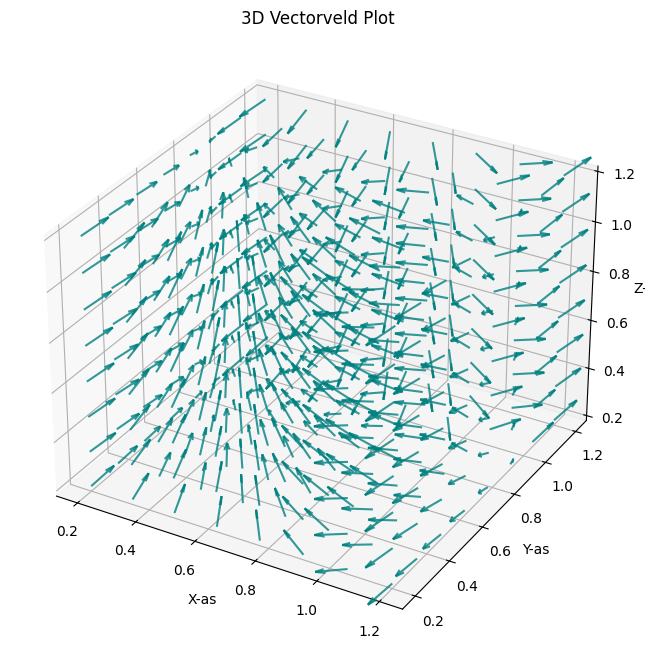

In [50]:
# 1. Maak de figuur en de 3D-as aan (slechts één keer!)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# 2. Het rooster
xr = np.linspace(0.2, 1.2, 8)
yr = np.linspace(0.2, 1.2, 8)
zr = np.linspace(0.2, 1.2, 8)
X_grid, Y_grid, Z_grid = np.meshgrid(xr, yr, zr)

# 3. Bereken de vectoren
v_veld_func = sp.lambdify((x, y, z), Bmat, 'numpy')
U, V, W = v_veld_func(X_grid, Y_grid, Z_grid)

# 4. Normaliseer (voor gelijke lengtes zoals gevraagd in Opdracht 7)
mag = np.sqrt(U**2 + V**2 + W**2)
# Voorkom delen door nul
mag[mag == 0] = 1
U_norm, V_norm, W_norm = U/mag, V/mag, W/mag

# 5. Plotten op de 3D-as
# We gebruiken 'color' in plaats van 'cmap' omdat 3D quiver geen directe cmap mapping heeft
ax.quiver(X_grid, Y_grid, Z_grid, U_norm, V_norm, W_norm, 
          length=0.1, normalize=True, color='teal', alpha=0.8)

# 6. Afwerking
ax.set_xlabel('X-as')
ax.set_ylabel('Y-as')
ax.set_zlabel('Z-as')
ax.set_title('3D Vectorveld Plot')

plt.show()

# Divergentie, curl en potentiaal

Het gradientveld $\mathbf{B}$ dat je gedefinieerd hebt in opgave 6 is een vectorveld, en dus kunnen we de curl en divergentie operatoren toepassen uit vectorcalculus. In het `sympy.vector` package zijn deze beschikbaar als `curl` en `divergence` welke als argument een vectorveld nodig hebben dat gedefinieerd is met behulp van een coordinatenstelsel (dus met posities **x**, **y**, **z** en basisvectoren $\mathbf{\hat{i}}$, $\mathbf{\hat{j}}$, $\mathbf{\hat{k}}$, net zoals in opgave 6.1).

**Opdracht 8.1**: Om zeker te zijn dat je doorhebt hoe je zo'n een vectorveld moet opstellen definieer je

$$\mathbf{F} = y\sin(x)~\mathbf{\hat{i}} + \sqrt{z}~\mathbf{\hat{j}} + xyz~\mathbf{\hat{k}} $$

en bereken vervolgens de divergentie. Je zou (uiteraard) $xy + y\cos(x)$ moeten bekomen.

In [53]:
F = sp.Function('F')
F = y*sp.sin(x)*C.i + sp.sqrt(z)*C.j + x*y*z*C.k
F

(C.y*sin(C.x))*C.i + (sqrt(C.z))*C.j + C.x*C.y*C.z*C.k

In [56]:
div = sv.divergence(F)
div

C.x*C.y + C.y*cos(C.x)

**Opdracht 8.2**: herinner je dat we $\mathbf{B} = \nabla\phi$ hebben gedefinieerd, en dat $\phi$ een harmonische functie is. Wat wil dit zeggen over $\nabla \cdot \mathbf{B}$ en $\nabla \times \mathbf{B}$? Gebruik het tekstvak hierondera(dubbelklik) om uit te leggen wat er zal gebeuren, test vervolgens je vermoeden door de divergentie en curl van $\mathbf{B}$ te berekenen.

> Je kan dit tekstvak gebruiken.
> het veld is bronvrij (solenoidaal)
> het veld is rotatievrij (irrotationeel)

In [57]:
divB = sv.divergence(B)
curlB = sv.curl(B)
display(divB, curlB)

0

0

**Opdracht 9**: aangezien $\mathbf{B}$ een conservatief vectorveld is (dat wil zeggen, de gradient van een scalaire functie) bestaat er ook een potentiaalfunctie voor $\mathbf{B}$. Sympy kan controleren of een vectorveld conservatief is met behulp van de methode `is_conservative`. Indien dit het geval is kan sympy ook de bijhorende potentiaalfunctie uitrekenen met behulp van `scalar_potential`, welke twee argumenten nodig heeft: het vectorveld en het coordinatenstelsel waarin het veld gedefinieerd is. Controleer of $\mathbf{B}$ wel degelijk conservatief is en bereken vervolgens de potentiaalfunctie. Vergelijk met $\phi$.

In [59]:
sv.is_conservative(B)

True

In [60]:
sv.scalar_potential(B, C)

sin(C.x*pi)*sin(C.y*pi)*sinh(sqrt(2)*C.z*pi)/sinh(sqrt(2)*pi)

**Opdracht 10**: probeer eens om een potentiaalfunctie uit te rekenen op een vectorveld dat niet conservatief is. Wat gebeurt er?

# Coordinatenstelsels

Hieronder zal het nut van coordinatenstelsels duidelijk worden. Zoals je weet hangt de vorm van de $\nabla$-operator af van de geometrie: de divergentie van een vectorveld in een Cartesiaans assenstelsel is eenvoudigweg de som van de afgeleiden van de componentsfuncties, maar in een cilindrisch assenstelsel bijvoorbeeld moeten er extra termen in rekening gebracht worden.

Dit doet sympy allemaal automatisch op basis van het meegegeven coordinatenstelsel. De voorbeeldjes hieronder berekenen de gradient van een willekeurige functie in verschillende geometriën. Merk op dat er eenvoudig kan gewisseld worden door het argument `transformation` mee te geven. 

In [ ]:
f1 = sp.Function("F_1")
f2 = sp.Function("F_2")
f3 = sp.Function("F_3")

### 1. $\nabla$ in Cartesische coordinaten

In [ ]:
C = sv.CoordSys3D("")
x, y, z = C.x, C.y, C.z
vecfield = f1(x, y, z) * C.i + f2(x, y, z) * C.j + f3(x, y, z) * C.k

In [ ]:
display("gradient:", sv.gradient(f1(x, y, z)))
display("divergentie:", sv.divergence(vecfield))
display("curl:", sv.curl(vecfield))

### 2. $\nabla$ in cilindrische coordinaten

In [ ]:
Cyl = sv.CoordSys3D("", transformation="cylindrical")
r, th, z = Cyl.r, Cyl.theta, Cyl.z
vecfield = f1(r, th, z) * Cyl.i + f2(r, th, z) * Cyl.j + f3(r, th, z) * Cyl.k

In [ ]:
display("gradient:", sv.gradient(f1(r, th, z)))
display("divergentie:", sv.divergence(vecfield))
display("curl:", sv.curl(vecfield))

### 3. $\nabla$ in sferische coordinaten

In [ ]:
S = sv.CoordSys3D("", transformation="spherical")
r, th, phi = S.r, S.theta, S.phi
vecfield = f1(r, th, phi) * S.i + f2(r, th, phi) * S.j + f3(r, th, phi) * S.k

In [ ]:
display("gradient:", sv.gradient(f1(r, th, phi)))
display("divergentie:", sv.divergence(vecfield))
display("curl:", sv.curl(vecfield))

# Lijn- en oppervlakte-integralen, flux door een oppervlak

In [ ]:
a = sp.symbols("a", positive=True)
t = sp.symbols("t")

C = sv.CoordSys3D("")
x, y, z = C.x, C.y, C.z

Het `sympy.vector` package bevat routines om lijn- en oppervlakte-integralen uit te rekenen. Een voorbeeldje staat hieronder, waarbij we de integraal van de functie "1" berekenen over een cirkel met straal $a$ gelegen op hoogte $z=1$. Eerst definiëren we de regio waarover we integreren als een `ParametricRegion`, op een analoge manier als eerder in dit werkblad. De parametrisatie van de cirkel is vrij eenvoudig:

In [ ]:
circle = sv.ParametricRegion((a * sp.cos(t), a * sp.sin(t), 1), (t, 0, 2*sp.pi))
display(circle.definition)

Vervolgens kunnen we de integraal uitrekenen met behulp van de [`vector_integrate`](https://docs.sympy.org/latest/modules/vector/vector_integration.html) methode, welke automatisch de correcte integraal zal opstellen afhankelijk van welke parameters je meegeeft en hoe deze er uitzien.

In [ ]:
sv.vector_integrate(1, circle)

Het eerste argument van `vector_integrate` is dus de functie "1", en het tweede argument is de functie waarover we integreren.

**Opdracht 11**: bereken de integraal 

$$\int_\mathcal{C}~\frac{1}{(2y^2+1)^{3/2}}~ds $$

met $\mathcal{C}$ de parabool die de doorsnede is van de kegel $z^2 = x^2 + y^2$ en het vlak $x+z=1$. Je zal eerst zelf een parametrisatie van de kromme $\mathcal{C}$ moeten bedenken.

**Opmerking**: de parametrisatie van de kromme $\mathcal{C}$ was eenvoudig zelf te vinden, maar voor moeilijkere opgaven is dit echter niet altijd het geval. Gelukkig kan sympy zélf een parametrisatie opstellen door gebruik te maken van een [`ImplicitRegion`](https://docs.sympy.org/latest/modules/vector/api/classes.html#implicitregion). Dit is analoog aan een `ParametricRegion`, behalve dat je hier geen parametrisatie meegeeft maar een impliciete vergelijking. Bestudeer het voorbeeldje hieronder, waar we gebruik maken van zo'n `ImplicitRegion` voor de opgave die je net opgelost hebt.

De vergelijking voor $\mathcal{C}$ wordt gegeven door $x^2 + y^2 - (1 - x)^2 = 0$, wat we meegeven als een van de parameters. Vervolgens vragen we voor een parametrisatie in $t$ met behulp van `rational_parametrization`.

In [ ]:
eq_c = sp.Eq(x**2 + y**2 - (1 - x)**2, 0)
c_implicit = sv.ImplicitRegion((x, y), eq_c)
display(c_implicit)

xy_param = c_implicit.rational_parametrization(t)
display(xy_param)

Dit geeft een mogelijke parametrisatie voor $(x, y)$, welke we kunnen invullen in $z = 1 - x$ om tenslotte de parametrisatie voor $z$ te vinden.

**Opdracht 12**: bereken de lijnintegraal van het vectorveld
$$\mathbf{F} = 8x^2yz~\mathbf{\hat{i}} + 5z~\mathbf{\hat{j}} - 4xy ~\mathbf{\hat{k}}$$ over de kromme
$\mathbf{r}(t) = t~\mathbf{\hat{i}} + t^2~\mathbf{\hat{j}} + t^3~\mathbf{\hat{k}}$ waarbij $t \in [0, 1]$. Denk eraan dat dit een vectorveld is, dus je zal gebruik moeten maken van een coordinatenstelsel. Je zou als antwoord 1 moeten bekomen.

<font color="red">**Opmerking**:</font> indien je een `ValueError` krijgt ben je waarschijnlijk meerdere coordinatenstelsels door elkaar aan het gebruiken (bijvoorbeeld **x** en **y** uit een Cartesisch en **z** uit een cilindrisch). 

**Opdracht 13**: Sympy kan zonder problemen integralen uitrekenen waarbij een van de grenzen afhankelijk is van de andere. Bereken de flux van het vectorveld $\mathbf{F} = z^2~\mathbf{\hat{k}}$ opwaarts doorheen het deel van de bol met straal $a$ in het eerste octant. Gebruik hiervoor een parametrisatie voor $u$ en $v$, waarbij je $u$ kan laten lopen van $0$ tot $\sqrt{a^2 - v^2}$ en $v$ van $0$ tot $a$.
Je zou op $\dfrac{\pi a^4}{8}$ moeten uitkomen.

**Opdracht 14**: integreer de functie $x^2 + y^2$ over het oppervlak met parametrisatie 

$$\mathbf{r}(u,v) = 2uv~\mathbf{\hat{i}} + (u^2-v^2)~\mathbf{\hat{j}} + (u^2+v^2)~\mathbf{\hat{k}}$$

waarbij 
$0 \leq v \leq 1$ en $-v \leq u \leq v$. Je zou $\dfrac{96\sqrt{2}}{35}$ moeten bekomen.

Merk op dat Sympy de integraal correct behandelt, of je nu een scalaire functie of een vectorveld meegeeft als integrand. Intern zal Sympy altijd het onderscheid maken tussen de verschillende gevallen, en meestal zal de methode `vector_integrate` aanroepen voldoende zijn om deze uit te rekenen.

# Examenvraag 2018-2019

We bekijken het vectorveld $\mathbf{F} = \left(z^2 + y^2 + \sin (x^2)\right)~\mathbf{\hat{i}} + (2xy + z)~\mathbf{\hat{j}} + (xz + 2yz)~\mathbf{\hat{k}}$ en beschouwen de lijnintegraal

$$\oint_\mathcal{C}~\mathbf{F} \bullet d\mathbf{r}$$

waarbij een parametrisatie voor de de in tegenwijzerszin georiënteerde gesloten kromme $C$ gegeven is door 

$$ C(t) = (4\sin t + 1)~\mathbf{\hat{i}} + (2\cos t)~\mathbf{\hat{j}} + (1 - 8\sin t - 2\cos t)~\mathbf{\hat{k}}$$

met $t \in [0, 2\pi]$. Deze kromme wordt bepaald door de intersectie van de cilinder $(x-1)^2 + 4y^2 = 16$ en het vlak $2x + y + z = 3$.

**a)** Definieer het vectorveld $\mathbf{F}$ met behulp van `sympy.vector` en zet dit om naar een matrix.

**b)** Vervolgens maken we een plot van de setup in 1 enkele figuur:

- Plot het vectorveld van $\mathbf{F}$ met behulp van `quiver`. Je zal eerst `lambdify` moeten gebruiken om het vectorveld te evalueren in het grid.
- Plot het vlak.
- Plot de kromme $\mathcal{C}$.

Een deel van de code is al gegeven en we hebben de cilinder al getekend.

In [ ]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection='3d')

# indeling van het grid
X = np.linspace(-3, 5, 100)
Y = np.linspace(-3, 5, 100)
Z = np.linspace(-12, 12, 100)

# opstellen en plotten van de cilinder
cylinder_x, cylinder_z = np.meshgrid(X, Z)
cylinder_y = np.sqrt(4 - (cylinder_x - 1)**2 / 4)
ax.plot_surface(cylinder_x, cylinder_y, cylinder_z, color="blue", alpha=0.3)
ax.plot_surface(cylinder_x, -cylinder_y, cylinder_z, color="blue", alpha=0.3)  # ook minteken omwille van y^2

# opstellen en plotten van het vlak

# VUL AAN



# opstellen en plotten van de kromme
trange = np.linspace(0, 2*np.pi, 100)

# VUL AAN



# opstellen en plotten van het vectorveld
xf, yf, zf = np.linspace(-3, 5, 8), np.linspace(-3, 5, 8), np.linspace(-12, 12, 8)
Xgrid, Ygrid, Zgrid = np.meshgrid(xf, yf, zf)

# VUL AAN




ax.set_xlim([-3.2, 5.2])
ax.set_ylim([-2.2, 2.2])
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()

**c)** bovenstaande integraal is vrij ingewikkeld, en je zal merken dat Sympy moeilijkheden heeft om deze rechtstreeks uit te rekenen. Het theorema van Stokes geeft ons echter een alternatief om zo'n type integralen om te zetten naar een eenvoudigere vorm, en laat ons toe om bovenstaande integraal te herschrijven als
$$ \iint_\Omega \left(\nabla \times \mathbf{F}\right) \cdot \mathbf{\hat{N}}~dS $$

Uit de 3D plot die je net gemaakt hebt kan je zien dat het oppervlak $\Omega$ (de intersectie tussen de cilinder en het vlak) een elliptische schijf is. We geven je mee dat de (niet-genormaliseerde) normaal van deze schijf gelijk is aan $\mathbf{N} = 2\mathbf{\hat{i}} + \mathbf{\hat{j}} + \mathbf{\hat{k}}$, en dat de projectie op het $xy$-vlak een ellips is met lange as 4 en korte as 2. De centroïde van de elliptische schijf ligt op $(1, 0, 1)$.

Toon aan dat bovenstaande integraal gelijk is aan $24\pi$.

**Tip:** je kan de parametrisatie van de geprojecteerde ellips schrijven als $ (x, y) = \left(a\cos t, \dfrac{a}{2}\sin t\right)$ met $t \in [0, 2\pi]$.